# Classifier Validation & Generalisation Metrics

This notebook reads the trained classifier heads (saved by
`classifier_training.py`) and dives deeper into their generalisation
behaviour with graphical evidence:

1. **Load** the persisted models and metrics from MinIO.
2. **Cross-modality summary** — bar chart comparing CV accuracy and macro-F1.
3. **Base vs trained comparison** — quantifies the value of the trained
   head against kNN @ k=1 and kNN @ k=5 baselines on the same held-out
   test split; the figure is also saved to `docs/base_vs_trained.png`
   for the LaTeX report.
4. **Confusion matrices** — one heatmap per modality.
5. **Per-class precision and recall** — grouped bars per modality.
6. **Learning curves** — does the model benefit from more data?
7. **Calibration check** — confidence vs. correctness for each head.
8. **Embedding visualisation** — 2-D projections coloured by category.

Only the **audio** (PANNs CNN14) and **cymatics** (CLIP ViT-B/32) heads
are evaluated here. The text embedding encodes the category by construction
(its description starts with `"This is a {category} sound."`), so training a
classifier on it would produce a leaky, meaningless score; text embeddings
remain available for semantic search but are intentionally out of scope for
supervised evaluation.

The intent is to provide the reviewer with an honest picture of how the
classifier head generalises, not to claim a leaderboard result on a small
dataset.

## 1. Setup & Load Persisted Models

In [1]:
import os, sys, io, json

_NB_DIR  = os.path.abspath("")
_EZ_DIR  = os.path.abspath(os.path.join(_NB_DIR, ".."))
_PROJECT = os.path.abspath(os.path.join(_EZ_DIR, ".."))
for p in (_PROJECT, _EZ_DIR):
    if p not in sys.path:
        sys.path.insert(0, p)

from dotenv import load_dotenv
load_dotenv(os.path.join(_PROJECT, ".env"))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

In [2]:
from shared.minio_helpers import create_minio_client
from milvus_embeddings import (
    connect_milvus,
    load_exploitation_metadata,
    EXPLOITATION_BUCKET,
)
from classifier_training import (
    MODALITIES,
    MODELS_PREFIX,
    collect_labelled_uuids,
    trim_to_min_class_size,
    fetch_embeddings,
    build_xy,
    MIN_SAMPLES_PER_CLASS,
)

minio_client  = create_minio_client()
milvus_client = connect_milvus()

  Connected to Milvus at http://localhost:19530


In [3]:
def load_model_from_minio(client, modality):
    """Read the joblib model + metrics JSON for *modality* from MinIO."""
    model_key   = f"{MODELS_PREFIX}{modality['model_name']}.joblib"
    metrics_key = f"{MODELS_PREFIX}{modality['model_name']}.metrics.json"

    resp = client.get_object(EXPLOITATION_BUCKET, model_key)
    model = joblib.load(io.BytesIO(resp.read()))
    resp.close(); resp.release_conn()

    resp = client.get_object(EXPLOITATION_BUCKET, metrics_key)
    metrics = json.loads(resp.read().decode("utf-8"))
    resp.close(); resp.release_conn()
    return model, metrics


loaded = {}
for m in MODALITIES:
    try:
        model, metrics = load_model_from_minio(minio_client, m)
        loaded[m["key"]] = {"model": model, "metrics": metrics, "modality": m}
        print(f"  {m['key']:.<10s} loaded ({metrics['n_samples']} samples, "
              f"{metrics['n_classes']} classes)")
    except Exception as e:
        print(f"  {m['key']:.<10s} skipped — {e}")

if not loaded:
    raise RuntimeError(
        "No persisted classifiers found. Run "
        "`python exploitation_zone/classifier_training.py` first."
    )

  audio..... loaded (400 samples, 29 classes)
  cymatics.. loaded (400 samples, 29 classes)


## 2. Cross-Modality Summary

A quick glance at how the three modalities compare on the held-out test
split and the 5-fold cross-validation. The CV bars carry error bars equal
to the fold standard deviation.

In [4]:
summary = pd.DataFrame(
    [
        {
            "modality":      k,
            "n_samples":     v["metrics"]["n_samples"],
            "n_classes":     v["metrics"]["n_classes"],
            "cv_acc_mean":   v["metrics"]["cv_accuracy_mean"],
            "cv_acc_std":    v["metrics"]["cv_accuracy_std"],
            "cv_f1_macro":   v["metrics"]["cv_f1_macro_mean"],
            "cv_f1_std":     v["metrics"]["cv_f1_macro_std"],
            "test_acc":      v["metrics"]["test_accuracy"],
            "test_f1_macro": v["metrics"]["test_f1_macro"],
        }
        for k, v in loaded.items()
    ]
).set_index("modality")
summary

,n_samples,n_classes,cv_acc_mean,cv_acc_std,cv_f1_macro,cv_f1_std,test_acc,test_f1_macro
modality,,,,,,,,
audio,400,29,0.771875,0.027063,0.782322,0.032777,0.7375,0.673954
cymatics,400,29,0.118750,0.033657,0.071989,0.023944,0.2250,0.157927


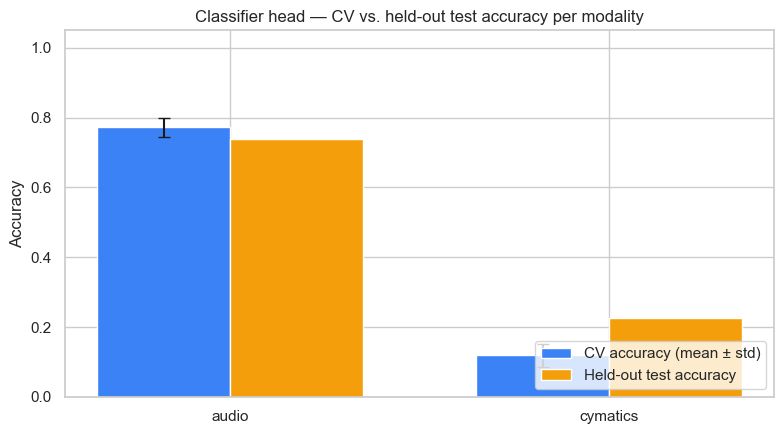

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
modalities = list(summary.index)
x = np.arange(len(modalities))
w = 0.35

ax.bar(
    x - w / 2, summary["cv_acc_mean"], width=w,
    yerr=summary["cv_acc_std"], capsize=4,
    label="CV accuracy (mean ± std)", color="#3b82f6",
)
ax.bar(
    x + w / 2, summary["test_acc"], width=w,
    label="Held-out test accuracy", color="#f59e0b",
)
ax.set_xticks(x); ax.set_xticklabels(modalities)
ax.set_ylim(0, 1.05); ax.set_ylabel("Accuracy")
ax.set_title("Classifier head — CV vs. held-out test accuracy per modality")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

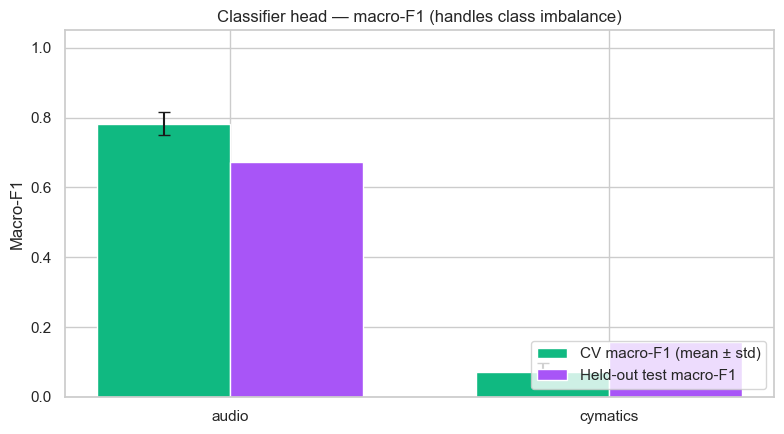

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(
    x - w / 2, summary["cv_f1_macro"], width=w,
    yerr=summary["cv_f1_std"], capsize=4,
    label="CV macro-F1 (mean ± std)", color="#10b981",
)
ax.bar(
    x + w / 2, summary["test_f1_macro"], width=w,
    label="Held-out test macro-F1", color="#a855f7",
)
ax.set_xticks(x); ax.set_xticklabels(modalities)
ax.set_ylim(0, 1.05); ax.set_ylabel("Macro-F1")
ax.set_title("Classifier head — macro-F1 (handles class imbalance)")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 3. Base vs Trained Comparison

The trained logistic-regression head only justifies its place in the pipeline
if it improves on the simpler retrieval baselines that the previous
deliverable already shipped. This section quantifies that gap on the
**same stratified held-out test split** for each modality, by comparing
three predictors that consume the **same** PANNs / CLIP embeddings:

- **kNN @ k=1** — predicted label is the nearest neighbour's category
  from the Milvus collection. This is, in spirit, what the previous
  deliverable returned as "audio classification" and "cymatics
  classification".
- **kNN @ k=5** — majority vote over the 5 nearest neighbours, a
  slightly more robust retrieval baseline.
- **Trained head** — the `StandardScaler → LogisticRegression(balanced)`
  pipeline fitted by `classifier_training.py`.

For every modality we report accuracy and macro-F1 side by side. The
resulting figure is also persisted to `docs/base_vs_trained.png` so it
can be embedded directly in the LaTeX report.

In [7]:
# ── Live fetch — the rest of the notebook also rebuilds these, but the
# comparison cell needs them up front so we don't depend on cell order.
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def _build_head():
    """Same architecture as classifier_training.py — kept in lock-step here
    so the comparison reflects the exact pipeline persisted to MinIO."""
    return Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf",    LogisticRegression(
            max_iter=2000, class_weight="balanced",
            solver="lbfgs", random_state=42,
        )),
    ])


def evaluate_predictors(X, y, *, k_values=(1, 5), test_fraction=0.20, random_state=42):
    """Evaluate kNN baselines and the trained head on the SAME held-out split."""
    try:
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=test_fraction, stratify=y, random_state=random_state,
        )
    except ValueError:
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=test_fraction, random_state=random_state,
        )

    rows = []
    for k in k_values:
        # Cosine distance — matches the Milvus HNSW metric used at retrieval time.
        knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
        knn.fit(X_tr, y_tr)
        y_pred = knn.predict(X_te)
        rows.append({
            "predictor": f"kNN k={k}",
            "accuracy":  accuracy_score(y_te, y_pred),
            "f1_macro":  f1_score(y_te, y_pred, average="macro", zero_division=0),
        })

    head = _build_head().fit(X_tr, y_tr)
    y_pred = head.predict(X_te)
    rows.append({
        "predictor": "Trained head",
        "accuracy":  accuracy_score(y_te, y_pred),
        "f1_macro":  f1_score(y_te, y_pred, average="macro", zero_division=0),
    })
    return pd.DataFrame(rows)


# Make sure we have per-modality feature matrices (rebuild if section 5 hasn't run yet).
if "datasets" not in globals() or not datasets:
    rows  = load_exploitation_metadata(minio_client)
    raw_l = collect_labelled_uuids(rows)
    labels_l = trim_to_min_class_size(raw_l, MIN_SAMPLES_PER_CLASS)
    uuids_l  = list(labels_l.keys())
    datasets = {}
    for m in MODALITIES:
        if m["key"] not in loaded:
            continue
        vectors = fetch_embeddings(milvus_client, m["collection"], m["vector_field"], uuids_l)
        X, y, _ = build_xy(labels_l, vectors)
        datasets[m["key"]] = (X, y)

comparisons = {key: evaluate_predictors(X, y) for key, (X, y) in datasets.items()}
for key, df in comparisons.items():
    print(f"\n{key}:")
    print(df.to_string(index=False))

  Loaded 406 rows from exploitation-zone/metadata/observations.csv

audio:
   predictor  accuracy  f1_macro
     kNN k=1    0.7625  0.708372
     kNN k=5    0.7125  0.726351
Trained head    0.7375  0.673954

cymatics:
   predictor  accuracy  f1_macro
     kNN k=1     0.200  0.184441
     kNN k=5     0.125  0.062726
Trained head     0.225  0.157927



Saved figure: /Users/arman/Desktop/2026-sprinrg/BDM/Cymatics/BDM-Cymatics/docs/base_vs_trained.png


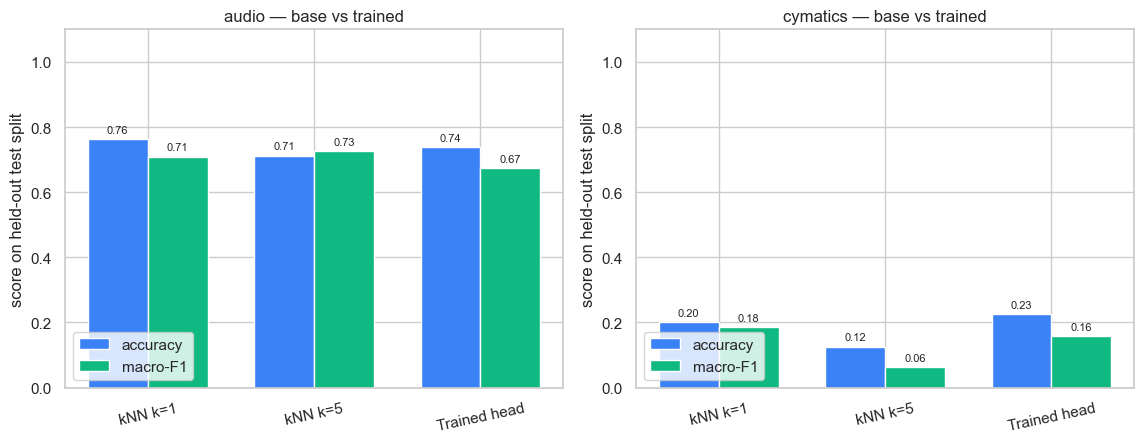

In [8]:
# Grouped bar chart per modality — accuracy and macro-F1 side by side.
predictors = ["kNN k=1", "kNN k=5", "Trained head"]
n_panels   = len(comparisons)
fig, axes  = plt.subplots(1, n_panels, figsize=(5.8 * n_panels, 4.6), squeeze=False)

for ax, (key, df) in zip(axes[0], comparisons.items()):
    df = df.set_index("predictor").loc[predictors]
    x  = np.arange(len(predictors))
    w  = 0.36

    ax.bar(x - w / 2, df["accuracy"], width=w, color="#3b82f6", label="accuracy")
    ax.bar(x + w / 2, df["f1_macro"], width=w, color="#10b981", label="macro-F1")

    # Numerical labels above each bar — keeps the chart readable in the report.
    for i, (acc, f1) in enumerate(zip(df["accuracy"], df["f1_macro"])):
        ax.text(i - w / 2, acc + 0.02, f"{acc:.2f}", ha="center", fontsize=8)
        ax.text(i + w / 2, f1  + 0.02, f"{f1:.2f}",  ha="center", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(predictors, rotation=12)
    ax.set_ylim(0, 1.10)
    ax.set_ylabel("score on held-out test split")
    ax.set_title(f"{key} — base vs trained")
    ax.legend(loc="lower left")

plt.tight_layout()

# Persist the figure for the LaTeX report.
import os as _os
_OUT_DIR = _os.path.abspath(_os.path.join(_PROJECT, "docs"))
_os.makedirs(_OUT_DIR, exist_ok=True)
_OUT_PATH = _os.path.join(_OUT_DIR, "base_vs_trained.png")
fig.savefig(_OUT_PATH, dpi=150, bbox_inches="tight")
print(f"\nSaved figure: {_OUT_PATH}")

plt.show()

## 3. Confusion Matrices

The confusion matrix tells us *which* categories the head confuses with
*which*. We display the row-normalised version so that values are recall
rates per true class and the diagonal can be read directly as per-class
accuracy.

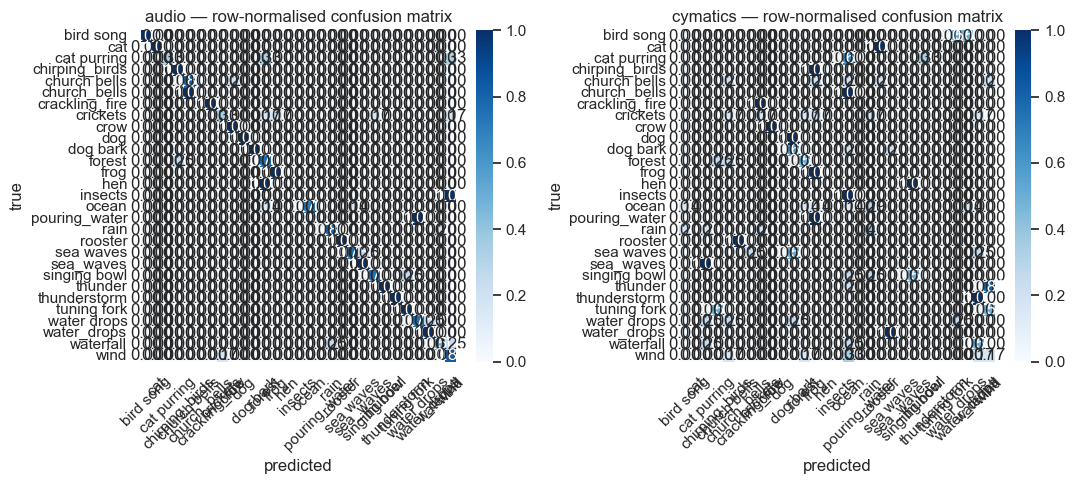

In [9]:
n = len(loaded)
fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5.0), squeeze=False)

for ax, (key, item) in zip(axes[0], loaded.items()):
    metrics = item["metrics"]
    cm      = np.asarray(metrics["confusion_matrix"], dtype=np.float64)
    classes = metrics["classes"]
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1e-9)

    sns.heatmap(
        cm_norm, ax=ax, annot=True, fmt=".2f", cmap="Blues", cbar=True,
        xticklabels=classes, yticklabels=classes, vmin=0.0, vmax=1.0,
    )
    ax.set_title(f"{key} — row-normalised confusion matrix")
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout(); plt.show()

## 4. Per-Class Precision and Recall

Useful to spot under-performing categories — for example, classes that the
model never predicts (recall = 0) or classes whose predictions are mostly
spurious (precision low).

Saved figure: /Users/arman/Desktop/2026-sprinrg/BDM/Cymatics/BDM-Cymatics/docs/per_class_metrics.png


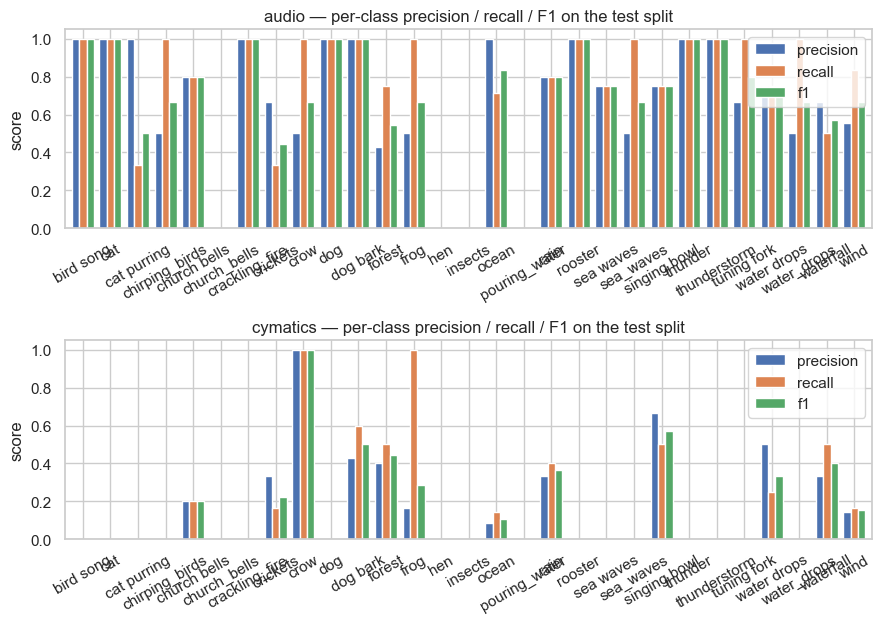

In [15]:
def per_class_frame(metrics):
    rows = []
    for cls in metrics["classes"]:
        rep = metrics["per_class_report"].get(cls, {})
        rows.append(
            {
                "class":     cls,
                "precision": rep.get("precision", 0.0),
                "recall":    rep.get("recall", 0.0),
                "f1":        rep.get("f1-score", 0.0),
                "support":   rep.get("support", 0),
            }
        )
    return pd.DataFrame(rows)


fig, axes = plt.subplots(len(loaded), 1, figsize=(9, 3.2 * len(loaded)), squeeze=False)
for ax, (key, item) in zip(axes[:, 0], loaded.items()):
    df = per_class_frame(item["metrics"]).set_index("class")
    df[["precision", "recall", "f1"]].plot.bar(ax=ax, width=0.8)
    ax.set_title(f"{key} — per-class precision / recall / F1 on the test split")
    ax.set_ylim(0, 1.05); ax.set_ylabel("score"); ax.set_xlabel("")
    ax.legend(loc="upper right")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()

# Persist the figure for the LaTeX report.
import os as _os
_OUT_DIR = _os.path.abspath(_os.path.join(_PROJECT, "docs"))
_os.makedirs(_OUT_DIR, exist_ok=True)
_OUT_PATH = _os.path.join(_OUT_DIR, "per_class_metrics.png")
fig.savefig(_OUT_PATH, dpi=150, bbox_inches="tight")
print(f"Saved figure: {_OUT_PATH}")

plt.show()

## 5. Learning Curves

Re-fit the same pipeline on growing training fractions and plot the
training and cross-validated scores. A growing gap suggests overfitting;
a flat curve near 1.0 on a tiny dataset is a warning that the metrics are
dominated by memorisation. We rebuild the feature matrices live from
Milvus to keep the curves consistent with the latest data.

In [11]:
rows = load_exploitation_metadata(minio_client)
raw_labels = collect_labelled_uuids(rows)
labels     = trim_to_min_class_size(raw_labels, MIN_SAMPLES_PER_CLASS)
uuids      = list(labels.keys())

datasets = {}
for m in MODALITIES:
    if m["key"] not in loaded:
        continue
    vectors = fetch_embeddings(milvus_client, m["collection"], m["vector_field"], uuids)
    X, y, _ = build_xy(labels, vectors)
    datasets[m["key"]] = (X, y)
    print(f"  {m['key']:.<10s} X={X.shape}")

  Loaded 406 rows from exploitation-zone/metadata/observations.csv
  audio..... X=(400, 2048)
  cymatics.. X=(400, 512)


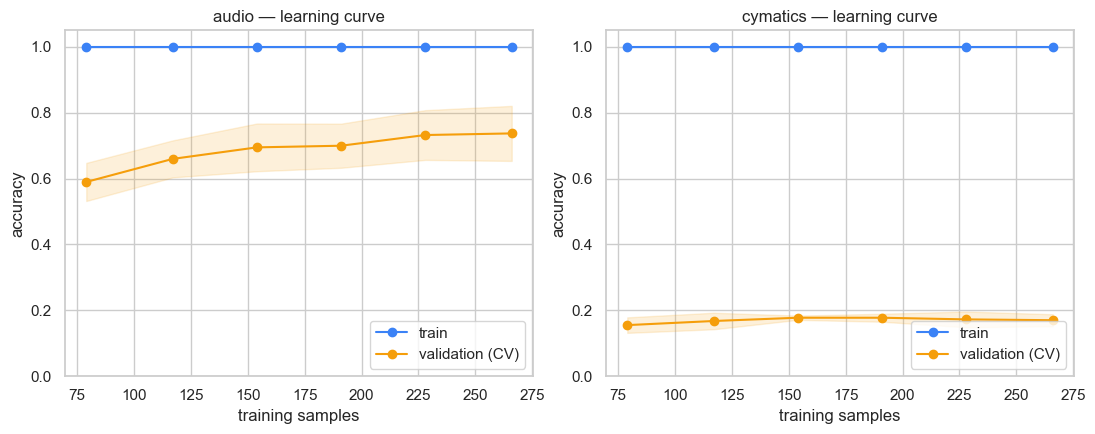

In [12]:
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


def build_pipeline():
    return Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf",    LogisticRegression(
            max_iter=2000, class_weight="balanced",
            solver="lbfgs", random_state=42,
        )),
    ])


fig, axes = plt.subplots(1, len(datasets), figsize=(5.5 * len(datasets), 4.5), squeeze=False)
fractions = np.linspace(0.3, 1.0, 6)

for ax, (key, (X, y)) in zip(axes[0], datasets.items()):
    try:
        sizes, train_scores, val_scores = learning_curve(
            build_pipeline(), X, y,
            train_sizes=fractions, cv=3, scoring="accuracy",
            random_state=42, shuffle=True,
        )
        train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
        val_mean,   val_std   = val_scores.mean(axis=1),   val_scores.std(axis=1)

        ax.plot(sizes, train_mean, marker="o", color="#3b82f6", label="train")
        ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#3b82f6")
        ax.plot(sizes, val_mean, marker="o", color="#f59e0b", label="validation (CV)")
        ax.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#f59e0b")
        ax.set_title(f"{key} — learning curve")
        ax.set_xlabel("training samples")
        ax.set_ylabel("accuracy")
        ax.set_ylim(0, 1.05); ax.legend(loc="lower right")
    except ValueError as e:
        ax.set_title(f"{key} — not enough samples"); ax.axis("off")
        ax.text(0.5, 0.5, str(e), ha="center", va="center", wrap=True)

plt.tight_layout(); plt.show()

## 6. Calibration Check

Logistic regression returns probabilities. If our reported confidence
matches reality, the model is *calibrated* — for example, predictions made
with 0.8 confidence should be correct roughly 80\% of the time. A reliability
diagram plots predicted confidence against empirical accuracy in each bin.

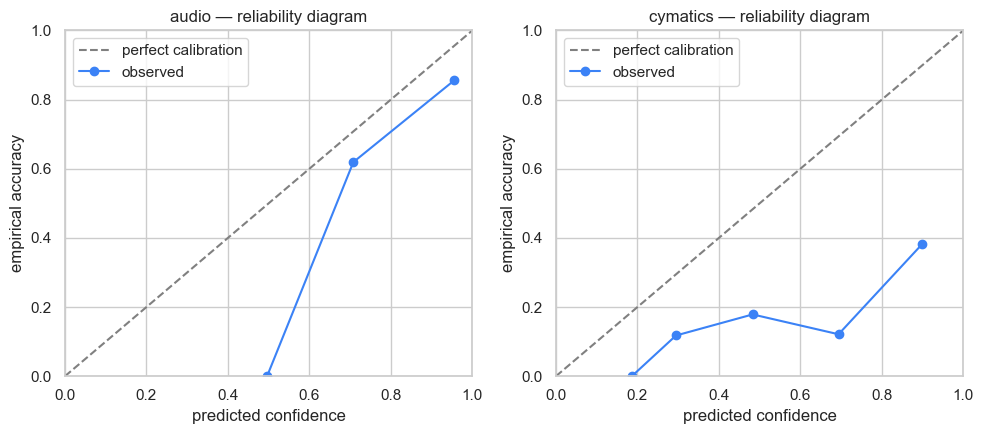

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, len(datasets), figsize=(5.0 * len(datasets), 4.5), squeeze=False)

for ax, (key, (X, y)) in zip(axes[0], datasets.items()):
    try:
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.25, stratify=y, random_state=42,
        )
        pipe = build_pipeline().fit(X_tr, y_tr)
        proba = pipe.predict_proba(X_te)
        conf  = proba.max(axis=1)
        pred  = pipe.classes_[proba.argmax(axis=1)]
        correct = (pred == y_te).astype(int)

        # Bin by confidence and plot empirical accuracy per bin.
        prob_true, prob_pred = calibration_curve(correct, conf, n_bins=5, strategy="uniform")
        ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
        ax.plot(prob_pred, prob_true, marker="o", color="#3b82f6", label="observed")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel("predicted confidence")
        ax.set_ylabel("empirical accuracy")
        ax.set_title(f"{key} — reliability diagram")
        ax.legend(loc="upper left")
    except ValueError as e:
        ax.set_title(f"{key} — split failed"); ax.axis("off")
        ax.text(0.5, 0.5, str(e), ha="center", va="center", wrap=True)

plt.tight_layout(); plt.show()

## 7. Embedding Visualisation

Project the modality embeddings to 2 dimensions with PCA and colour them
by category. Well-clustered points are a sign that the pretrained
representation already separates the categories and that a linear head is
an appropriate choice.

/var/folders/sn/qpm3h_mj7bjcyn0gntfr9wh00000gn/T/ipykernel_83263/2304250675.py:12: UserWarning: 
The palette list has fewer values (20) than needed (29) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(
/var/folders/sn/qpm3h_mj7bjcyn0gntfr9wh00000gn/T/ipykernel_83263/2304250675.py:12: UserWarning: 
The palette list has fewer values (20) than needed (29) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


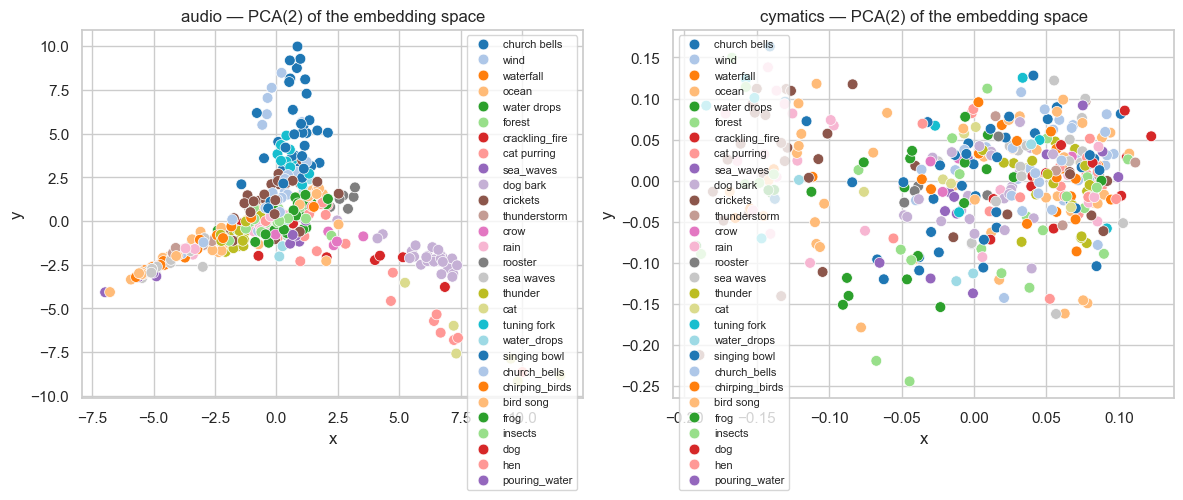

In [14]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, len(datasets), figsize=(6.0 * len(datasets), 5.0), squeeze=False)
palette = sns.color_palette("tab20", n_colors=20)

for ax, (key, (X, y)) in zip(axes[0], datasets.items()):
    if X.shape[0] < 3:
        ax.set_title(f"{key} — not enough points"); ax.axis("off")
        continue
    coords = PCA(n_components=2, random_state=42).fit_transform(X)
    df = pd.DataFrame({"x": coords[:, 0], "y": coords[:, 1], "category": y})
    sns.scatterplot(
        data=df, x="x", y="y", hue="category", ax=ax,
        palette=palette[: len(set(y))], s=60, edgecolor="white", linewidth=0.5,
    )
    ax.set_title(f"{key} — PCA(2) of the embedding space")
    ax.legend(loc="best", fontsize=8, frameon=True)

plt.tight_layout(); plt.show()

## Summary

We have:

1. Loaded the three persisted classifier heads and their metrics reports.
2. Compared the modalities on accuracy and macro-F1 with explicit CV error bars.
3. Inspected the confusion matrices to identify which categories are confused.
4. Reviewed per-class precision and recall to expose imbalance effects.
5. Plotted learning curves to assess overfitting and the value of more data.
6. Checked the calibration of the confidence scores (reliability diagram).
7. Visualised the embedding space with PCA to motivate the linear-head choice.

These plots collectively answer *how well* and *under which conditions* the
classifier head generalises, and they should be re-rendered after every
exploitation-zone run so the team can track quality as the dataset grows.